In [ ]:
import gzip
import os
from pathlib import Path
import re

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from dna_features_viewer import GraphicFeature, GraphicRecord
from Bio import SeqIO, SeqRecord, Phylo

cwd = os.getcwd()
if cwd.endswith('notebook'):
    os.chdir('..')
    cwd = os.getcwd()

In [13]:
sns.set_palette('colorblind')
sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.8)
plt.rcParams['font.family'] = 'Helvetica'

palette = sns.color_palette().as_hex()

data_folder = (Path('.') / 'data').resolve()
assert data_folder.is_dir()

gene_context_folder = data_folder / 'gene_context'
assert gene_context_folder.is_dir()

In [36]:
inputs = [
    ('Haloferax_larsenii_S5a1', 'annot.gff', 'extdb:pgaptmp_002090'),
    ('Haloferax_larsenii_ZJ206', 'GCF_000336955.1_ASM33695v1_genomic.gff.gz', 'WP_007545272.1'),
    ('Haloferax_mediterranei', 'GCF_000306765.2_ASM30676v2_genomic.gff.gz', 'WP_004057439.1'),
    # ('Haloferax_elongans', 'GCF_000336755.1_ASM33675v1_genomic.gff.gz', 'WP_049907546.1'),
    ('Halococcus_sediminicola', 'GCF_000755245.1_ASM75524v1_genomic.gff.gz', 'WP_394297709.1'),
]

In [7]:
def parse_gff(path : Path):
    gff_csv = pd.read_csv(
        path,
        sep='\t',
        comment='#',
        header=None,
        names=[
            'contig_id',
            'source',
            'type',
            'start',
            'end',
            'na1',
            'strand',
            'na2',
            'metadata',
        ],
    )

    def parse_protein_id(metadata : str):
        m = re.match(r'^.*protein_id=([^;]+).*$', metadata)
        if m is not None:
            return m[1]
        else:
            return None
        
    def parse_description(metadata : str):
        m = re.match(r'^.*product=([^;]+).*$', metadata)
        if m is not None:
            return m[1]
        else:
            return None

    gff_csv = gff_csv[gff_csv['type'] == 'CDS'].reset_index(drop=True)
    gff_csv['protein_id'] = gff_csv['metadata'].apply(parse_protein_id)
    gff_csv['description'] = gff_csv['metadata'].apply(parse_description)

    return gff_csv.drop_duplicates(['contig_id', 'protein_id']).reset_index(drop=True).set_index('protein_id')


In [8]:
def get_context(gff_df, core_protein_id, n_upstream=9_000, n_downstream=9_000):
    gff_row = gff_df.loc[core_protein_id]

    contig_id = gff_row['contig_id']
    start = max(gff_row['start'] - n_upstream, 1)
    end = gff_row['end'] + n_downstream

    return gff_df[
        (gff_df['contig_id'] == contig_id) &
        (gff_df['start'] >= start) &
        (gff_df['start'] < end) &
        (gff_df['end'] > start) &
        (gff_df['end'] <= end)
    ].copy()

In [9]:
def plot_genes(aoi_df, color_map=None, label_map=None, ax=None, figure_width=20, no_labels=False, default_color='#cccccc'):
    features = []
    start = aoi_df['start'].min()
    end = aoi_df['end'].max()
    length = end - start + 1

    for _, row in aoi_df.iterrows():
        if no_labels:
            label = None
        elif label_map is not None:
            label = label_map[row.name]
        else:
            label = row['description']
    
        if color_map is not None and row.name in color_map:
            color = color_map[row.name]
        else:
            color = default_color

        features.append(
            GraphicFeature(
                start=row.start, 
                end=row.end, 
                strand=1 if row.strand == '+' else -1, 
                color=color,
                label=label,
            )
        )
    
    record = GraphicRecord(first_index=start, sequence_length=length, features=features)
    ax, _ = record.plot(figure_width=figure_width, ax=ax, with_ruler=True)
    ax.grid(False)
    return ax

,contig_id,source,type,start,end,na1,strand,na2,metadata,description
protein_id,,,,,,,,,,
extdb:pgaptmp_002085,Haloferax,Protein Homology,CDS,1962730,1964010,.,-,0,ID=cds-pgaptmp_002085;Parent=gene-pgaptmp_0020...,FAD-dependent oxidoreductase
extdb:pgaptmp_002086,Haloferax,Protein Homology,CDS,1964105,1965274,.,+,0,ID=cds-pgaptmp_002086;Parent=gene-pgaptmp_0020...,pyridoxal-phosphate dependent enzyme
extdb:pgaptmp_002087,Haloferax,Protein Homology,CDS,1965375,1966079,.,+,0,ID=cds-pgaptmp_002087;Parent=gene-pgaptmp_0020...,metal-dependent transcriptional regulator
extdb:pgaptmp_002088,Haloferax,Protein Homology,CDS,1966076,1966771,.,+,0,ID=cds-pgaptmp_002088;Parent=gene-pgaptmp_0020...,TMEM165/GDT1 family protein
extdb:pgaptmp_002089,Haloferax,Protein Homology,CDS,1966871,1967518,.,+,0,ID=cds-pgaptmp_002089;Parent=gene-pgaptmp_0020...,LysE family translocator
extdb:pgaptmp_002090,Haloferax,Protein Homology,CDS,1967591,1968463,.,-,0,ID=cds-pgaptmp_002090;Parent=gene-pgaptmp_0020...,alpha/beta hydrolase
extdb:pgaptmp_002091,Haloferax,Protein Homology,CDS,1968621,1969667,.,+,0,ID=cds-pgaptmp_002091;Parent=gene-pgaptmp_0020...,NAD(P)-dependent glycerol-1-phosphate dehydrog...
extdb:pgaptmp_002092,Haloferax,Protein Homology,CDS,1969845,1970309,.,+,0,ID=cds-pgaptmp_002092;Parent=gene-pgaptmp_0020...,GNAT family N-acetyltransferase
extdb:pgaptmp_002093,Haloferax,Protein Homology,CDS,1970388,1971017,.,+,0,ID=cds-pgaptmp_002093;Parent=gene-pgaptmp_0020...,DUF420 domain-containing protein


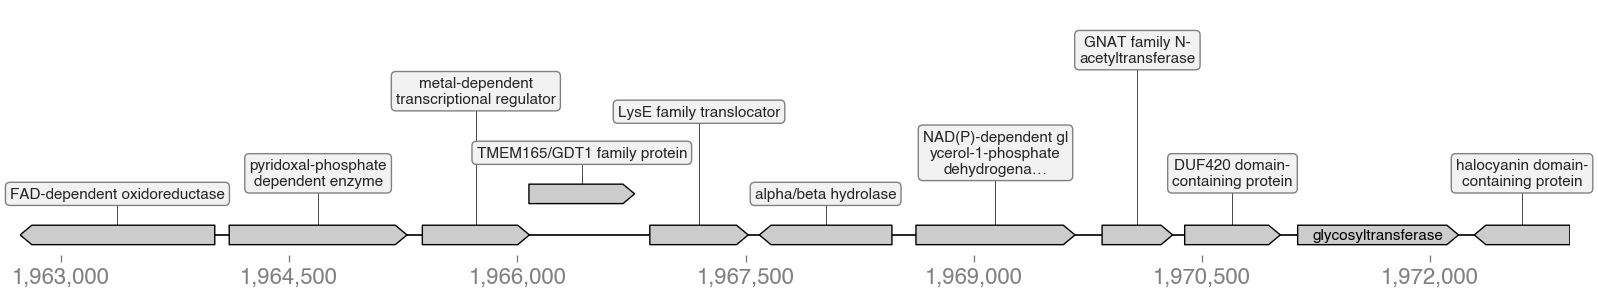

In [17]:
s5a1_gff = parse_gff(gene_context_folder / 'genomes' / 'Haloferax_larsenii_S5a1' / 'annot.gff')
ab_context = get_context(s5a1_gff, 'extdb:pgaptmp_002090', n_upstream=5_000, n_downstream=5_000)

plot_genes(ab_context);

ab_context

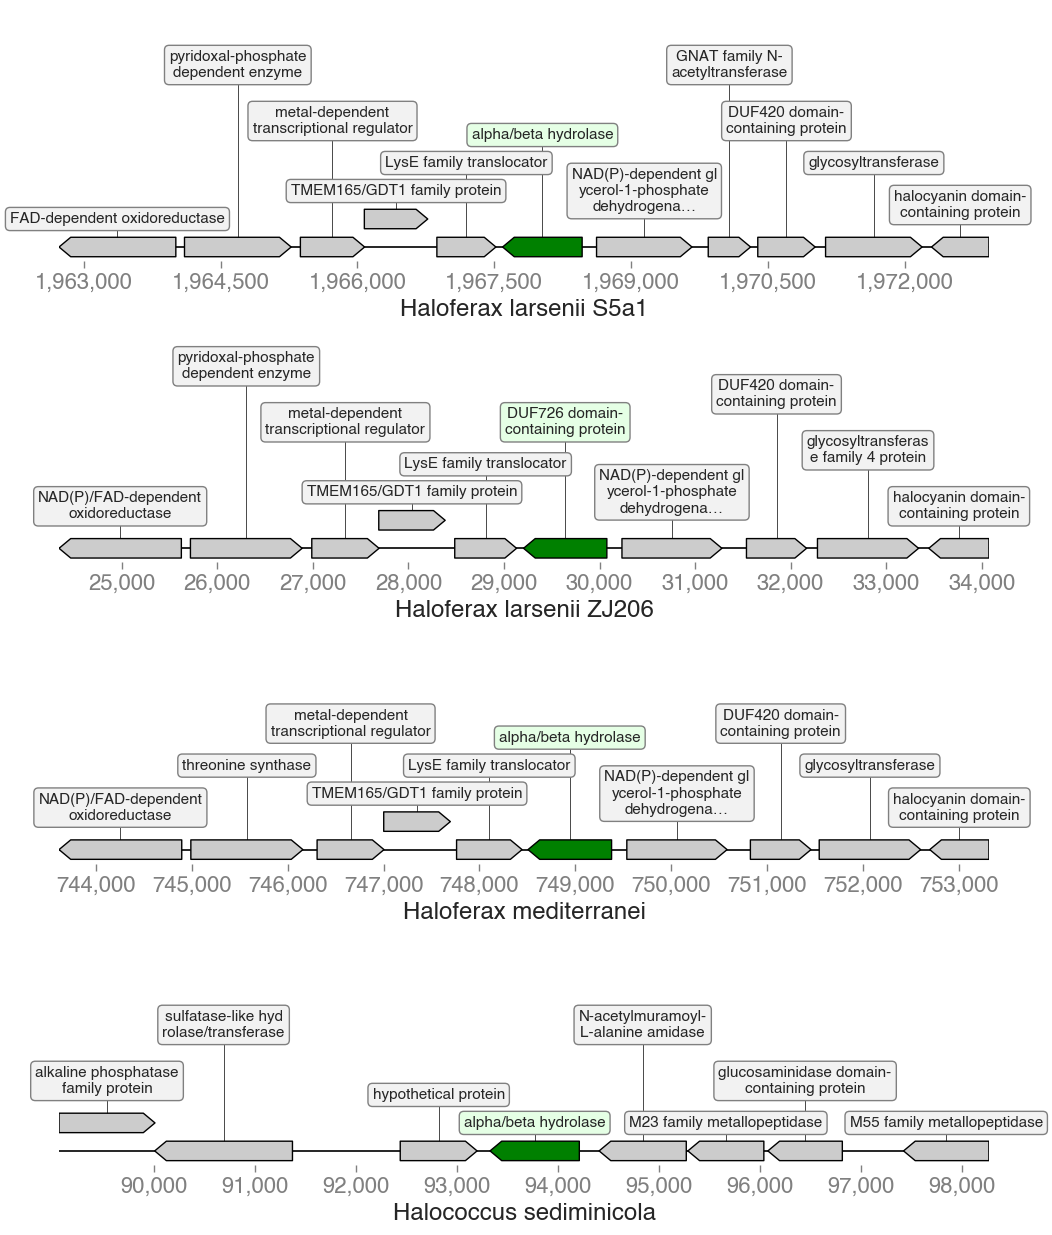

In [44]:
n_upstream = n_downstream = 5_000
f, axes = plt.subplots(len(inputs), 1, figsize=(12, 15))
axes = axes.flatten()

for i, (species_folder, gff_name, protein_id) in enumerate(inputs):
    ax = axes[i]
    gff = parse_gff(gene_context_folder / 'genomes' / species_folder / gff_name)
    context = get_context(gff, protein_id, n_upstream=n_upstream, n_downstream=n_downstream)
    plot_genes(context, ax=ax, color_map={protein_id: 'green'}, no_labels=False);
    ax.set_xlabel(species_folder.replace('_', ' '))



In [ ]:
f.savefig(gene_context_folder / 'Cinquedea_gene_context_raw.pdf', dpi=300, bbox_inches='tight')